In [25]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import torch 
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import Accuracy, Recall

In [3]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
print(df["Outcome"].sum())
print(len(df["Outcome"]))

268
768


In [16]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv")
y = df["Outcome"]
x = df.drop(columns = "Outcome")
real_1 = x[y == 1]
real_0 = x[y == 0]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=623)

scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
real_1 = scaler.transform(real_1)
real_0 = scaler.transform(real_0)


x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.from_numpy(y_train.values).float()
y_test = torch.from_numpy(y_test.values).float()
real_1 = torch.tensor(real_1, dtype=torch.float32)

In [35]:
print(x)

tensor([[0.4118, 0.5126, 0.6066,  ..., 0.5544, 0.0538, 0.4706],
        [0.2941, 0.7940, 0.6885,  ..., 0.5872, 0.1354, 0.1569],
        [0.1765, 0.3920, 0.5738,  ..., 0.4844, 0.0820, 0.3529],
        ...,
        [0.2353, 0.7337, 0.6967,  ..., 0.4307, 0.0474, 0.1176],
        [0.3529, 0.5779, 0.4918,  ..., 0.5022, 0.0713, 0.3725],
        [0.2941, 0.5879, 0.7541,  ..., 0.5082, 0.1106, 0.3333]])


In [6]:
import random
import os
import numpy as np
import torch

def set_seed(seed=42):
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    np.random.seed(seed)        

set_seed(616)

In [12]:
class VAE(nn.Module):

    def __init__(self, input_dim=8, hidden_dim=32, latent_dim=4):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return F.sigmoid(self.fc3(h)) 

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

def vae_loss(recon_x, x, mu, logvar, kl_weight=0.01):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + (kl_weight * kl_loss)
    return total_loss, recon_loss, kl_loss

vae_dataset = TensorDataset(real_1)
vae_loader = DataLoader(vae_dataset, batch_size=64, shuffle=True)

VAE_model = VAE()
optimizer = AdamW(VAE_model.parameters(), lr=0.001)

epochs = 400

for epoch in range(epochs):
    VAE_model.train()
    total_VAEloss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    kl_weight = min(1.0, epoch / 50.0) * 0.1 

    for batch in vae_loader:
        batch_data = batch[0]
        
        optimizer.zero_grad()
        recon, mu, logvar = VAE_model(batch_data)
        VAEloss, recon_loss, kl_loss = vae_loss(recon, batch_data, mu, logvar, kl_weight)

        VAEloss.backward()
        optimizer.step()
        
        total_VAEloss += VAEloss.item() * len(x)
        total_recon_loss += recon_loss.item() * len(x)
        total_kl_loss += kl_loss.item() * len(x)

    total_samples = len(real_1)
    avg_loss = total_VAEloss / total_samples
    avg_recon_loss = total_recon_loss / total_samples
    avg_kl_loss = total_kl_loss / total_samples

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f} | "
            f"Recon: {avg_recon_loss:.4f} | "
            f"KL: {avg_kl_loss:.4f} (wt: {kl_weight:.3f})"
        )

Epoch [1/400] Loss: 0.6820 | Recon: 0.6820 | KL: 0.0087 (wt: 0.000)
Epoch [10/400] Loss: 0.6154 | Recon: 0.6140 | KL: 0.0816 (wt: 0.018)
Epoch [20/400] Loss: 0.5971 | Recon: 0.5916 | KL: 0.1464 (wt: 0.038)
Epoch [30/400] Loss: 0.5863 | Recon: 0.5834 | KL: 0.0504 (wt: 0.058)
Epoch [40/400] Loss: 0.5800 | Recon: 0.5790 | KL: 0.0134 (wt: 0.078)
Epoch [50/400] Loss: 0.5770 | Recon: 0.5755 | KL: 0.0147 (wt: 0.098)
Epoch [60/400] Loss: 0.5756 | Recon: 0.5738 | KL: 0.0184 (wt: 0.100)
Epoch [70/400] Loss: 0.5754 | Recon: 0.5732 | KL: 0.0223 (wt: 0.100)
Epoch [80/400] Loss: 0.5728 | Recon: 0.5700 | KL: 0.0283 (wt: 0.100)
Epoch [90/400] Loss: 0.5742 | Recon: 0.5711 | KL: 0.0314 (wt: 0.100)
Epoch [100/400] Loss: 0.5739 | Recon: 0.5705 | KL: 0.0337 (wt: 0.100)
Epoch [110/400] Loss: 0.5744 | Recon: 0.5706 | KL: 0.0384 (wt: 0.100)
Epoch [120/400] Loss: 0.5742 | Recon: 0.5699 | KL: 0.0431 (wt: 0.100)
Epoch [130/400] Loss: 0.5750 | Recon: 0.5702 | KL: 0.0475 (wt: 0.100)
Epoch [140/400] Loss: 0.5727 | 

In [18]:
def sampling_fn(batch_size = 80):

    batch_size = batch_size
    latent_dim = 4 

    tensor = torch.randn(batch_size, latent_dim)
    y_tensor = torch.zeros(batch_size)

    new_data = VAE_model.decode(tensor).detach()

    x_train_sampling = torch.cat((x_train, new_data), dim=0)
    y_train_sampling = torch.cat((y_train, y_tensor), dim=0)

    perm_with_sampling = torch.randperm(x_train_sampling.size(0))
    x_train_sampling = x_train_sampling[perm_with_sampling]
    y_train_sampling = y_train_sampling[perm_with_sampling]

    return x_train_sampling, y_train_sampling

print("ok")

ok


In [44]:
def recon_error_fn(x, y):

    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x - x_hat)
        x_augmented = torch.cat((x, recon_error), dim=1) 

    perm = torch.randperm(x_augmented.size(0))
    x_train_recon = x_augmented[perm]
    y_train_recon = y[perm]

    return x_train_recon, y_train_recon
print("ok")


ok


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


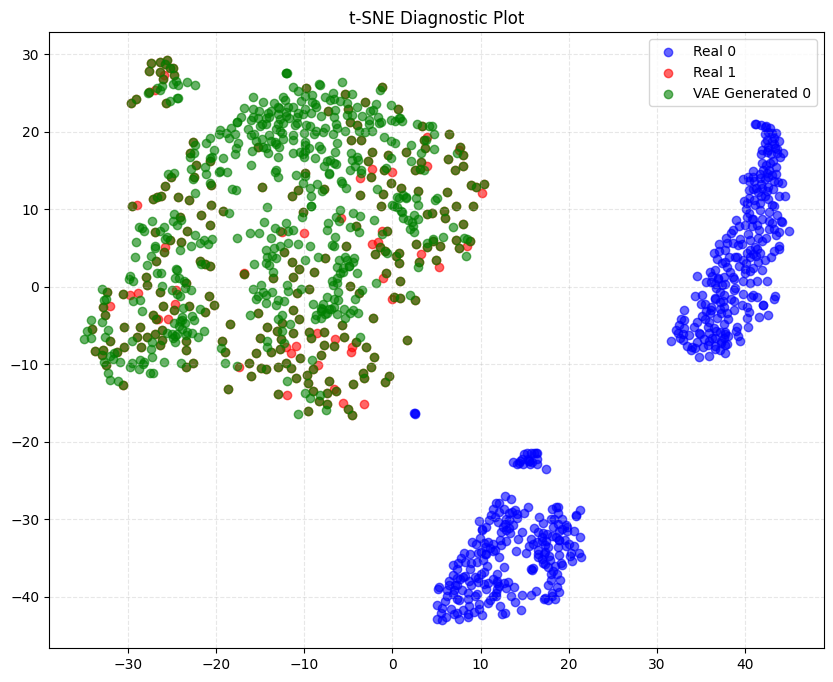

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

X_real_0 = x[y == 0]
X_real_1 = real_1
X_vae_1, _ = sampling_fn(80)
X = np.concatenate([X_real_0, X_real_1, X_vae_1], axis=0)

y = np.concatenate(
    [
        np.zeros(len(X_real_0)),
        np.ones(len(X_real_1)),
        np.ones(len(X_vae_1)) * 2,  
    ]
)


tsne = TSNE(n_components=2, perplexity=55, n_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
colors = ["blue", "red", "green"]
labels = ["Real 0", "Real 1", "VAE Generated 0"]

for i in range(3):
    idx = y == i
    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        c=colors[i],
        label=labels[i],
        alpha=0.6,
    )
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend()
plt.title("t-SNE Diagnostic Plot")
plt.savefig("tsne_diagnostic_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [41]:
class ResBlock(nn.Module):
    def __init__(self, features = 512, bottleneck_features = 64):
        super().__init__()

        self.bn1 = nn.BatchNorm1d(features)
        self.fn1 = nn.Linear(features, bottleneck_features)
        
        self.bn2 = nn.BatchNorm1d(bottleneck_features)
        self.fn2 = nn.Linear(bottleneck_features, bottleneck_features)

        self.bn3 = nn.BatchNorm1d(bottleneck_features)
        self.fn3 = nn.Linear(bottleneck_features, features)
        
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        out = F.relu(self.bn1(x))
        out = self.dropout(self.fn1(out))
        
        out = F.relu(self.bn2(out))
        out = self.fn2(out)
        
        out = F.relu(self.bn3(out))
        out = self.fn3(out)
        
        return x + out

class BranchBlock(nn.Module):
    def __init__(self, features = 512, depth = 3):
        super().__init__()
        self.res_layers = nn.ModuleList([
            ResBlock(features = features) for _ in range(depth)
        ])

    def forward(self, x):
        for layer in self.res_layers:
            x = layer(x)
        return x

class Detection_model(nn.Module):
    def __init__(self, dim = 16, num_resBlocks = 5, num_branchs = 5, gate = False):
        super().__init__()
        self.input = nn.Linear(dim, 512)
        self.bn_in = nn.BatchNorm1d(512)
        
        self.fn1 = nn.Linear(512, 512)
        self.bn512_1 = nn.BatchNorm1d(512)

        self.parallel_branchs = nn.ModuleList([
            BranchBlock(features = 512, depth = num_resBlocks) for _ in range(num_branchs)
        ])
        
                
        self.fn2 = nn.Linear(512, 512)
        self.bn512_2 = nn.BatchNorm1d(512)
        self.output = nn.Linear(512, 1)

        self.gate = gate
        if self.gate:
            self.weights = ElementWeight(features=512)
        else:
            self.register_parameter('weights', None)

    def forward(self, x):
        x = F.relu(self.bn_in(self.input(x)))
        x = F.relu(self.bn512_1(self.fn1(x)))

        parallel = sum(blocks(x) for blocks in self.parallel_branchs)
        
        if self.gate:
            parallel = self.weights(parallel)
        
        x = x + parallel 

        x = F.relu(self.bn512_2(self.fn2(x)))
        x = self.output(x)

        return x

    def prediction(self, x):
        return self.forward(x)

class NN(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.input = nn.Linear(dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fn = nn.Linear(512, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.output = nn.Linear(512, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.input(x)))
        x = F.relu(self.bn2(self.fn(x)))
        x = self.output(x)

        return x

class ElementWeight(nn.Module):
    def __init__(self, features=512):
        super().__init__()
        self.fn1 = nn.Linear(features, features)

    def forward(self, x):
        weights = torch.sigmoid(self.fn1(x))
        return x * weights

print("ok")

ok


In [47]:
mode = 8

if mode == 0:
    training_data = x_train
    target = y_train
    detection_model = NN(dim = 8)
    
elif mode == 1:
    training_data, target = sampling_fn()
    detection_model = NN(dim = 8)
    
elif mode == 2:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = NN(dim = 16)
    
elif mode == 3:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = NN(dim = 16)
    
elif mode == 4:
    training_data = x_train
    target = y_train
    detection_model = Detection_model(dim = 8)
    
elif mode == 5:
    training_data, target = sampling_fn()
    detection_model = Detection_model(dim = 8)
    
elif mode == 6:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = Detection_model(dim = 16)
    
elif mode == 7:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = Detection_model(dim = 16, gate = True)

elif mode == 8:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = Detection_model(dim = 16, gate = True)

else:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = Detection_model(dim = 22, gate = False)

train_dataset = TensorDataset(training_data, target)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

#detection_model = Detection_model(num_resBlocks = 20, num_branchs = 5)
optim = AdamW(detection_model.parameters(), lr = 0.0001)

scheduler = ReduceLROnPlateau(optim, mode='min', factor=0.3, patience=10)

accuracy = Accuracy(task = "binary")
recall = Recall(task="binary")

epochs = 200

pos_weight = torch.tensor([0.8])

for epoch in range(epochs):
    detection_model.train()
    total_loss = 0
    
    epoch_preds = []
    epoch_targets = []

    for batch_x, batch_y in train_loader:
        optim.zero_grad()
        
        y_pred_logits = detection_model(batch_x)
        
        y_pred_logits = y_pred_logits.squeeze() 
        batch_y = batch_y.squeeze()

        loss = F.binary_cross_entropy_with_logits(y_pred_logits, batch_y, pos_weight = pos_weight)
        loss.backward()
        optim.step()

        total_loss += loss.item() * len(batch_y)
        
        y_pred_prob = torch.sigmoid(y_pred_logits)
        epoch_preds.append(y_pred_prob.detach())
        epoch_targets.append(batch_y.detach())
        
    avg_loss = total_loss / len(training_data)

    torch.nn.utils.clip_grad_norm_(detection_model.parameters(), max_norm=1.0)
    scheduler.step(avg_loss)
    
    all_preds = torch.cat(epoch_preds)
    all_targets = torch.cat(epoch_targets)
    
    acc_score = accuracy(all_preds, all_targets)
    recall_score = recall(all_preds, all_targets)
    
    if (epoch+1) % 10 == 0:
        
        current_lr = optim.param_groups[0]['lr']
        print(f"epoch:[{epoch+1}/{epochs}]  loss: {avg_loss:.4f}  acc: {acc_score:.4f}  recall:{recall_score:.4f}  lr:{current_lr:.10f}") 


epoch:[10/200]  loss: 0.1815  acc: 0.9294  recall:0.8571  lr:0.0001000000
epoch:[20/200]  loss: 0.0522  acc: 0.9942  recall:0.9866  lr:0.0001000000
epoch:[30/200]  loss: 0.0225  acc: 0.9986  recall:0.9955  lr:0.0001000000
epoch:[40/200]  loss: 0.0188  acc: 0.9971  recall:0.9955  lr:0.0001000000
epoch:[50/200]  loss: 0.0105  acc: 0.9986  recall:0.9955  lr:0.0001000000
epoch:[60/200]  loss: 0.0138  acc: 0.9971  recall:0.9955  lr:0.0000300000
epoch:[70/200]  loss: 0.0090  acc: 0.9986  recall:0.9955  lr:0.0000300000
epoch:[80/200]  loss: 0.0044  acc: 1.0000  recall:1.0000  lr:0.0000090000
epoch:[90/200]  loss: 0.0063  acc: 0.9986  recall:0.9955  lr:0.0000090000
epoch:[100/200]  loss: 0.0129  acc: 0.9957  recall:0.9911  lr:0.0000090000
epoch:[110/200]  loss: 0.0046  acc: 0.9986  recall:0.9955  lr:0.0000090000
epoch:[120/200]  loss: 0.0033  acc: 1.0000  recall:1.0000  lr:0.0000090000
epoch:[130/200]  loss: 0.0037  acc: 1.0000  recall:1.0000  lr:0.0000027000
epoch:[140/200]  loss: 0.0038  acc

In [48]:
if mode not in {0,1,4,5} :
    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x_test)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x_test - x_hat)
        x_augmented = torch.cat((x_test, recon_error), dim=1) 
    
    dataset = TensorDataset(x_augmented, y_test)

else:
    dataset = TensorDataset(x_test, y_test)
loader = DataLoader(dataset, batch_size=16, shuffle=False) 

all_preds = []
all_targets = []

detection_model.eval()

with torch.no_grad():
    for batch_x, batch_y in loader:
        
        y_logits = detection_model(batch_x)
        prob = torch.sigmoid(y_logits)
        
        y_pred = (prob >= 0.5).int()
        
        all_preds.append(y_pred.view(-1))
        all_targets.append(batch_y.view(-1))

final_preds = torch.cat(all_preds, dim=0)
final_targets = torch.cat(all_targets, dim=0).int()

accuracy.reset()
recall.reset()
metric_acc = accuracy(final_preds, final_targets)
metric_recall = recall(final_preds, final_targets)

print(f"--- 全測試集評估結果 ---")
print(f"Accuracy: {acc_score.item():.4f}")
print(f"Recall:   {recall_score.item():.4f}")

print("\n預測的前 50 筆結果:")
print(final_preds[:50].cpu().numpy()) 

--- 全測試集評估結果 ---
Accuracy: 1.0000
Recall:   1.0000

預測的前 50 筆結果:
[1 1 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0
 0 1 0 1 1 0 0 0 0 1 0 1 1]
